In [4]:
import numpy as np
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt

def padded_angular_spectrum(input_field, x_max_m, z_m, lambda_m, n_pad_pix):
    """
    Propagates an optical field using the Angular Spectrum method with padding.
    
    Parameters:
        input_field (ndarray): The input field (amplitude distribution).
        x_max_m (float): Maximum spatial extent (meters).
        z_m (float): Propagation distance (meters).
        lambda_m (float): Wavelength (meters).
        n_pad_pix (int): Number of pixels to pad.

    Returns:
        ndarray: Output field after propagation.
    """
    # Pad input field with zeros
    padded_input_field = np.pad(input_field, n_pad_pix, mode='constant')

    # Get sizes of padded and unpadded fields
    N_unpadded = input_field.shape[0]  # Assuming square input field
    N = padded_input_field.shape[0]  # Padded size

    # Compute spatial coordinates
    dx_m = 2 * x_max_m / (N_unpadded - 1)
    x_m = np.linspace(-(N - 1) * dx_m / 2, (N - 1) * dx_m / 2, N)

    # Compute frequency domain coordinates
    fx_max_pm = 1 / (2 * dx_m)  # Maximum frequency
    dfx_pm = 1 / (N * dx_m)  # Frequency step size

    if len(x_m) % 2 == 0:
        fx_pm = np.linspace(-fx_max_pm, fx_max_pm - dfx_pm, N)  # Even case
    else:
        fx_pm = np.linspace(-fx_max_pm, fx_max_pm, N)  # Odd case

    # Create frequency domain coordinate matrices
    kx_radpm = 2 * np.pi * fx_pm
    Kx_radpm, Ky_radpm = np.meshgrid(kx_radpm, kx_radpm)

    # Compute wavenumber
    k_radpm = 2 * np.pi / lambda_m

    # Compute transfer function (propagation kernel)
    kernel = np.exp(1j * z_m * np.sqrt(k_radpm**2 - Kx_radpm**2 - Ky_radpm**2))

    # Apply Angular Spectrum Method
    padded_input_fft = fftshift(fft2(padded_input_field))  # Forward FFT
    padded_output_fft = padded_input_fft * kernel  # Multiply by transfer function
    padded_output_field = ifft2(ifftshift(padded_output_fft))  # Inverse FFT

    # Crop out the original field size
    output_field = padded_output_field[n_pad_pix:n_pad_pix + N_unpadded,
                                       n_pad_pix:n_pad_pix + N_unpadded]

    return output_field

In [5]:
if __name__ == "__main__":
    # Parameters
    x_max = 0.01  # 10mm in meters (half-width, so total width is 20mm)
    z_m = 0.5     # 500mm in meters
    n_pixels = 2000  # 2000x2000 pixels
    lambda_m = 500e-9  # Example wavelength: 500nm in meters (you might need to adjust this)
    n_pad_pix = 0  # No padding for now

    # Create coordinate system using meshgrid
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)  # 2D array with constant z value of 0.5m

    # Create initial field (example: point source at center)
    # For a point source, we'll create a delta-like function at the center
    input_field = np.zeros((n_pixels, n_pixels), dtype=complex)
    center_idx = n_pixels // 2
    input_field[center_idx, center_idx] = 1.0  # Point source at center

    # Call the propagation function
    output_field = padded_angular_spectrum(
        input_field=input_field,
        x_max_m=x_max,
        z_m=z_m,
        lambda_m=lambda_m,
        n_pad_pix=n_pad_pix
    )

    # The result is stored in output_field
    print(f"Input field shape: {input_field.shape}")
    print(f"Output field shape: {output_field.shape}")
    print(f"Coordinate arrays shape: {X.shape}, {Y.shape}, {Z.shape}")

Input field shape: (2000, 2000)
Output field shape: (2000, 2000)
Coordinate arrays shape: (2000, 2000), (2000, 2000), (2000, 2000)


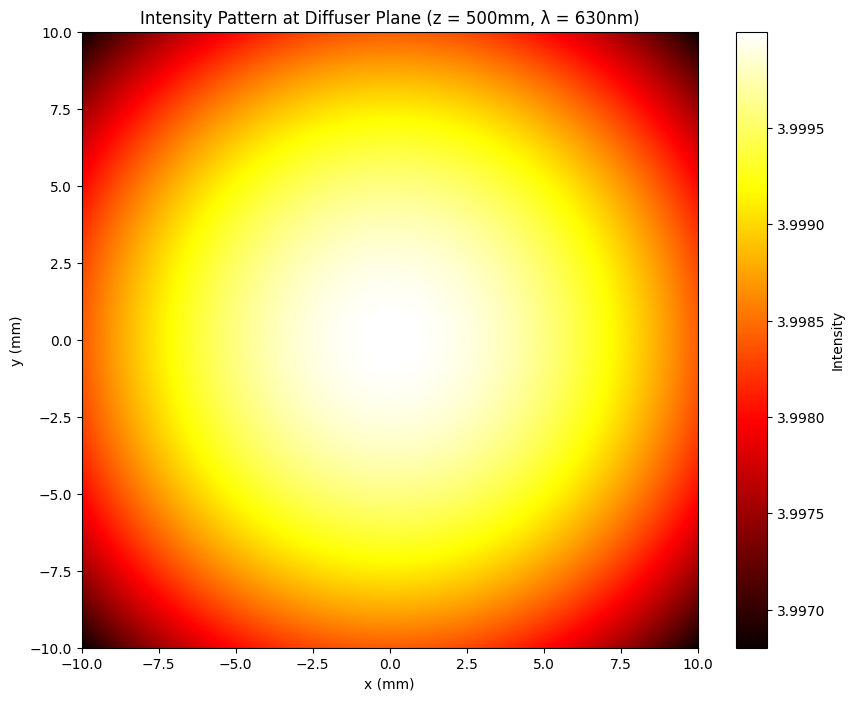

Input field shape: (2000, 2000)
Output field shape: (2000, 2000)
Maximum intensity: 4.00e+00
Minimum intensity: 4.00e+00


In [6]:
if __name__ == "__main__":
    # Parameters
    x_max = 0.01    # 10mm half-width in meters
    z_m = 0.5       # 500mm in meters
    n_pixels = 2000 # 2000x2000 pixels
    lambda_m = 630e-9  # 630nm wavelength in meters
    n_pad_pix = 0   # No padding

    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)

    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    
    # Calculate wave number
    k = 2 * np.pi / lambda_m
    
    # Create initial spherical wave field at diffuser plane
    # U(r) = A/r * exp(ikr), let's set A = 1 for simplicity
    A = 1.0
    input_field = (A / r) * np.exp(1j * k * r)

    # Propagate field (though in this case we're calculating directly at the plane)
    # We could skip propagation since we're calculating the field directly,
    # but let's use the propagator for consistency with the problem statement
    output_field = padded_angular_spectrum(
        input_field=input_field,
        x_max_m=x_max,
        z_m=0,  # No additional propagation needed since we calculated at z=500mm
        lambda_m=lambda_m,
        n_pad_pix=n_pad_pix
    )

    # Calculate intensity (magnitude squared) for plotting
    intensity = np.abs(output_field)**2

    # Plot the intensity
    plt.figure(figsize=(10, 8))
    plt.imshow(intensity, 
               extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000],
               cmap='hot')
    plt.colorbar(label='Intensity')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title('Intensity Pattern at Diffuser Plane (z = 500mm, λ = 630nm)')
    plt.show()

    # Print some information
    print(f"Input field shape: {input_field.shape}")
    print(f"Output field shape: {output_field.shape}")
    print(f"Maximum intensity: {np.max(intensity):.2e}")
    print(f"Minimum intensity: {np.min(intensity):.2e}")

# Question 3 and 4

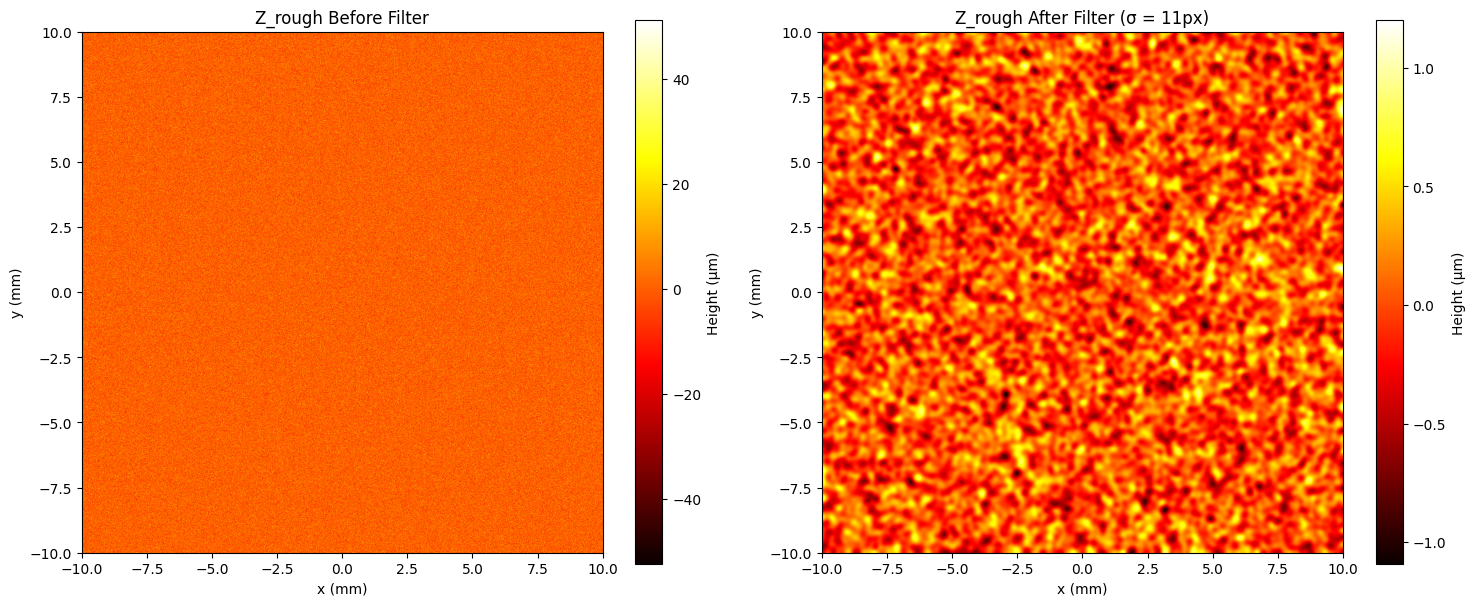

In [8]:
from scipy.ndimage import gaussian_filter

if __name__ == "__main__":
    # Parameters
    x_max = 0.01    # 10mm half-width in meters
    z_m = 0.5       # 500mm in meters
    n_pixels = 2000 # 2000x2000 pixels
    lambda_m = 630e-9  # 630nm wavelength in meters
    n_pad_pix = 0   # No padding
    sigma = sigma = 10e-6      # 10 μm roughness standard deviation in meters
    sigma_filter = 11    # Sigma for Gaussian filter in pixels

    # Add surface roughness
    zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)  # Gaussian random height with σ = 10 μm
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)

# Plot zrough_raw and zrough side by side
    plt.figure(figsize=(15, 6))
    
    # Left subplot: zrough_raw
    plt.subplot(1, 2, 1)
    plt.imshow(zrough_raw * 1e6,  # Convert to μm for better visibility
               cmap='hot',
               extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000])
    plt.colorbar(label='Height (μm)')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title('Z_rough Before Filter')

    # Right subplot: zrough
    plt.subplot(1, 2, 2)
    plt.imshow(zrough * 1e6,  # Convert to μm for better visibility
               cmap='hot',
               extent=[-x_max*1000, x_max*1000, -x_max*1000, x_max*1000])
    plt.colorbar(label='Height (μm)')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')
    plt.title('Z_rough After Filter (σ = 11px)')
    
    plt.tight_layout()
    plt.show()


## Question 5 

In [15]:
if __name__ == "__main__":
    # Parameters
    x_max = 0.01    # 10mm half-width in meters
    z_m = 0.5       # 500mm in meters
    n_pixels = 2000 # 2000x2000 pixels
    lambda_m = 630e-9  # 630nm wavelength in meters
    n_pad_pix = 0   # No padding
    sigma = 10e-6   # 10 μm roughness standard deviation in meters
    sigma_filter = 11    # Sigma for Gaussian filter in pixels
    n_refractive_index = 1 

    # Add surface roughness
    zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)  # Gaussian random height with σ = 10 μm
    zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)

    # Create coordinate system at diffuser plane (z = 500mm)
    x = np.linspace(-x_max, x_max, n_pixels)
    y = np.linspace(-x_max, x_max, n_pixels)
    X, Y = np.meshgrid(x, y)
    Z = np.full((n_pixels, n_pixels), z_m)

    # Phi rough 
    phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m

    # Calculate distance from point source at (0,0,0) to each point on diffuser
    r = np.sqrt(X**2 + Y**2 + Z**2)
    # Calculate wave number
    k = 2 * np.pi / lambda_m
    
    theta_lambda = k * r
    # Create initial spherical wave field at diffuser plane (without amplitude factor)
    input_field_u = np.exp(1j * theta_lambda)
    # Add the roughness phase
    U_diffuser = np.exp(1j * (theta_lambda + phi_rough))
    



# Question 6

/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_61003/1841877014.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


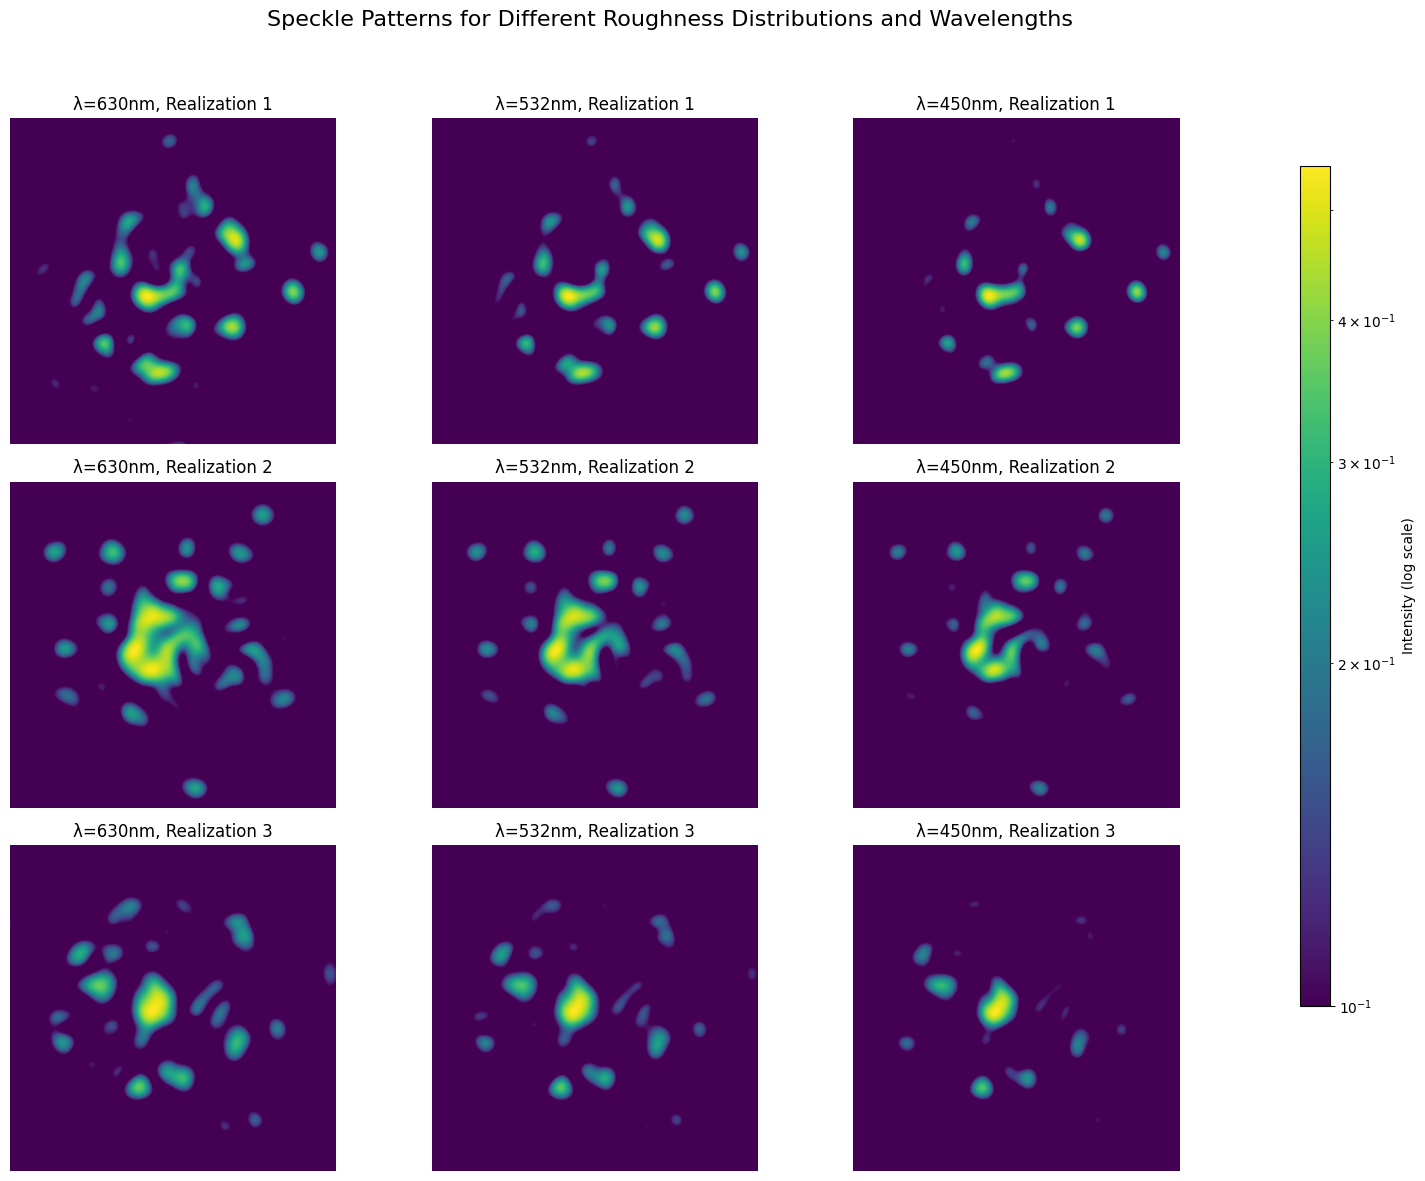

In [17]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Function to create a Gaussian kernel similar to MATLAB's fspecial('gaussian')
def fspecial_gaussian(shape=(3, 3), sigma=0.5):
    """
    Create a Gaussian kernel similar to MATLAB's fspecial('gaussian')
    
    Parameters:
    shape : tuple of int
        Size of the output kernel
    sigma : float
        Standard deviation of the Gaussian
        
    Returns:
    kernel : numpy.ndarray
        Normalized Gaussian kernel
    """
    m, n = [(ss-1.)/2. for ss in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x*x + y*y) / (2.*sigma*sigma))
    h[h < np.finfo(h.dtype).eps*h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h

if __name__ == "__main__":
        # Parameters
    x_max = 0.01      # 10mm half-width in meters
    z_m = 0.5         # 500mm in meters
    n_pixels = 2000   # 2000x2000 pixels
    lambda_m = 630e-9  # 630nm wavelength in meters
    n_pad_pix = 0     # No padding
    sigma = 10e-6     # 10 μm roughness standard deviation in meters
    sigma_filter = 11  # Sigma for Gaussian filter in pixels
    n_refractive_index = 1
    
    # Create additional wavelengths for comparison
    wavelengths = [630e-9, 532e-9, 450e-9]  # Red, Green, Blue wavelengths
    
    # Create multiple roughness distributions
    n_realizations = 3
    
    # Set up the figure for plotting
    fig, axs = plt.subplots(n_realizations, len(wavelengths), figsize=(15, 12))
    
    for i in range(n_realizations):
        # Add surface roughness - different realizations
        np.random.seed(i + 42)  # Set different seeds for reproducibility
        zrough_raw = sigma * np.random.randn(n_pixels, n_pixels)  # Gaussian random height with σ = 10 μm
        zrough = gaussian_filter(zrough_raw, sigma=sigma_filter)
        
        # Create coordinate system at diffuser plane (z = 500mm)
        x = np.linspace(-x_max, x_max, n_pixels)
        y = np.linspace(-x_max, x_max, n_pixels)
        X, Y = np.meshgrid(x, y)
        Z = np.full((n_pixels, n_pixels), z_m)
        
        # Calculate distance from point source at (0,0,0) to each point on diffuser
        r = np.sqrt(X**2 + Y**2 + Z**2)
        
        for j, lambda_m in enumerate(wavelengths):
            # Phi rough 
            phi_rough = 2 * np.pi * zrough * n_refractive_index / lambda_m
            
            # Calculate wave number
            k = 2 * np.pi / lambda_m
            
            theta_lambda = k * r
            # Create initial spherical wave field at diffuser plane (without amplitude factor)
            input_field_u = np.exp(1j * theta_lambda)
            # Add the roughness phase
            U_diffuser = np.exp(1j * (theta_lambda + phi_rough))
            
            # Low-pass filtering of the complex field using a Gaussian filter
            # This is equivalent to MATLAB's fspecial('gaussian') and imfilter() functions
            filter_size = 3  
            
            # Apply filtering to real and imaginary parts separately
            U_real_filtered = gaussian_filter(np.real(U_diffuser), sigma=sigma_filter)
            U_imag_filtered = gaussian_filter(np.imag(U_diffuser), sigma=sigma_filter)
            
            # Combine back to complex
            U_filtered = U_real_filtered + 1j * U_imag_filtered
            
            # Calculate intensity
            intensity = np.abs(U_filtered)**2
            
            # Extract a smaller region for display (central 400x400 pixels)
            display_size = 400
            center = n_pixels // 2
            start_idx = center - display_size // 2
            end_idx = center + display_size // 2
            
            intensity_display = intensity[start_idx:end_idx, start_idx:end_idx]
            
            # Plot the speckle pattern
            wavelength_nm = int(lambda_m * 1e9)
            ax = axs[i, j]
            im = ax.imshow(intensity_display, cmap='viridis', norm=LogNorm(vmin=0.1, vmax=np.max(intensity_display)))
            
            ax.set_title(f'λ={wavelength_nm}nm, Realization {i+1}')
            ax.axis('off')
    
    # Add a colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Intensity (log scale)')
    
    fig.suptitle('Speckle Patterns for Different Roughness Distributions and Wavelengths', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    # plt.savefig('speckle_patterns.png', dpi=300)
    plt.show()